# Fire-product comparison — run & inspect

This notebook drives `peatfire.fire_products_comparison`

## The data-transformation pipeline (one worked example: MCD64A1, 2017)


Key invariants:
- **Analysis CRS is always EPSG:5070** (equal-area) for area and grid comparison; the AOI's CRS is only a clip mask.
- The **common grid** (default 500 m, `how="max"` = "any sub-cell burn lights the cell") removes resolution as a confound.
- **Annual mode** ORs a product's monthly files into one yearly mask; **monthly mode** keeps each month separate and drops annual-only products.

Run the cells top to bottom. Each prints/plots the intermediate object it just made.

## 0. Setup & area of interest (AOI)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
AOI CRS      : EPSG:4269
AOI bounds   : [-84.321869  33.842316 -75.460621  36.588117]
AOI area km^2: 128598.3


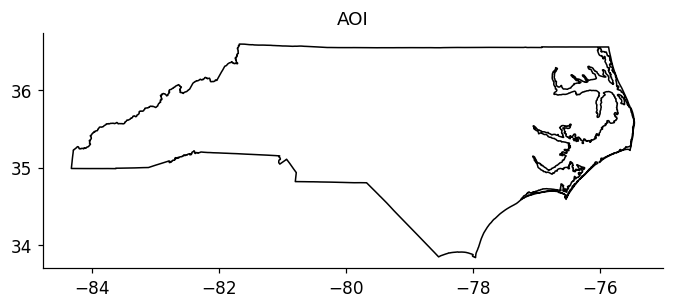

In [5]:
%load_ext autoreload
%autoreload 2

import geopandas as gpd
import matplotlib.pyplot as plt

from peatfire import data_path
from peatfire.preproc import clip_raster_to_mask, clip_vector_to_mask
from peatfire.fire_products_comparison import (
    FIRE_PRODUCTS, list_products, get_spec, load_standardized,
    build_common_grid, to_common_grid, burned_area_km2,
    annual_burned_area_series, stack_on_common_grid, agreement_matrix,
    period_totals_series, product_pair_scatter, total_least_squares, rmse,
    compare_fire_products,
    set_fire_style, plot_annual_series, plot_agreement_heatmap,
    plot_overlay_map, plot_product_scatter, plot_temporal_heatmap,
    plot_consensus_map
)

set_fire_style()

# AOI: swap this path for NC peatlands / non-peatlands later -- nothing else changes.
aoi = gpd.read_file(data_path("processed", "boundaries", "nc_boundary.gpkg"))
print("AOI CRS      :", aoi.crs)
print("AOI bounds   :", aoi.total_bounds)
print("AOI area km^2:", round(float(aoi.to_crs('EPSG:5070').area.sum()) / 1e6, 1))
aoi.plot(facecolor="none", edgecolor="black"); plt.title("AOI"); plt.show()

## 1. What products are registered, and which have data on disk?

The registry is the single source of truth. `directory` resolves each product's folder via `data_path`.

In [6]:
import pandas as pd
rows = []
for name in list_products():
    s = get_spec(name)
    n_files = len(sorted(s.directory.glob(s.glob))) if s.directory.exists() else 0
    rows.append({"product": name, "family": s.family, "res_m": s.native_res_m,
                 "temporal": s.temporal, "monthly": s.month_parser is not None,
                 "dir_exists": s.directory.exists(), "n_files": n_files,
                 "directory": str(s.directory)})
pd.DataFrame(rows).set_index("product")

,family,res_m,temporal,monthly,dir_exists,n_files,directory
product,,,,,,,
MCD64A1,burned_area,500.0,monthly,True,True,305,/Users/jinjiang-macair/Library/CloudStorage/On...
GABAM,burned_area,30.0,annual,False,True,29,/Users/jinjiang-macair/Library/CloudStorage/On...
FireCCI51,burned_area,250.0,monthly,True,True,240,/Users/jinjiang-macair/Library/CloudStorage/On...
FireCCIS311,burned_area,300.0,monthly,True,True,72,/Users/jinjiang-macair/Library/CloudStorage/On...
VIIRS,occurrence,375.0,events,False,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
SE_FireMap,severity,30.0,annual,False,True,23,/Users/jinjiang-macair/Library/CloudStorage/On...
MOSEV,severity,500.0,monthly,True,True,236,/Users/jinjiang-macair/Library/CloudStorage/On...
MTBS,severity,30.0,annual,False,True,40,/Users/jinjiang-macair/Library/CloudStorage/On...
USGS_BA,burned_area,30.0,annual,False,False,0,/Users/jinjiang-macair/Library/CloudStorage/On...


## 2. Load ONE product for ONE year, and inspect every sub-step

We trace MCD64A1 / 2017. First the raw clip (note it keeps a singleton `band` dim), then the
standardized annual mask the toolkit actually uses (band squeezed, months OR'd).

In [7]:
product, year = "MCD64A1", 2017
spec = get_spec(product)

# (a) the monthly files the loader will group for this year
files = sorted(spec.directory.glob(spec.glob))
files_2017 = [f for f in files if spec.year_parser(f) == year]
print(f"{product}: {len(files_2017)} monthly files for {year}")
for f in files_2017[:3]:
    print("   ", f.name, "-> month", spec.month_parser(f))

# (b) raw clip of a single month (in memory). Still has a band dimension.
one = clip_raster_to_mask(files_2017[0], aoi)
print("\nsingle clipped month -> dims:", dict(one.sizes), "| CRS:", one.rio.crs)

MCD64A1: 12 monthly files for 2017
    MCD64A1_A2017001_nc.tif -> month 1
    MCD64A1_A2017032_nc.tif -> month 2
    MCD64A1_A2017060_nc.tif -> month 3

single clipped month -> dims: {'band': 1, 'y': 659, 'x': 1951} | CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


annual mask name : MCD64A1
dims             : {'y': 659, 'x': 1951}
CRS              : PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] (native sinusoidal)
burned pixels    : 1040


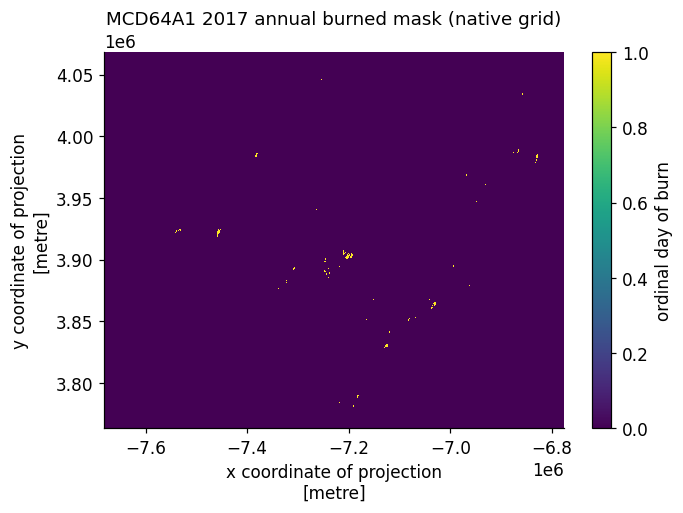

In [8]:
# (c) the standardized ANNUAL mask (band squeezed, 12 months OR'd, True=burned)
mask = load_standardized(product, year, aoi)
print("annual mask name :", mask.name)
print("dims             :", dict(mask.sizes))
print("CRS              :", mask.rio.crs, "(native sinusoidal)")
print("burned pixels    :", int((mask.values == True).sum()))
mask.astype("uint8").plot(); plt.title(f"{product} {year} annual burned mask (native grid)"); plt.show()

## 3. The common grid (the resolution-confound fix)

`build_common_grid` makes an empty EPSG:5070 reference grid over the AOI; `to_common_grid` warps any
product onto it with `how="max"`. Every product is matched to THIS grid, so none is privileged.

common grid CRS  : EPSG:5070
common grid shape: {'y': 688, 'x': 1559}
pixel size (m)   : (500.0, -500.0)

mask on common grid -> dims: {'y': 688, 'x': 1559} | CRS: EPSG:5070


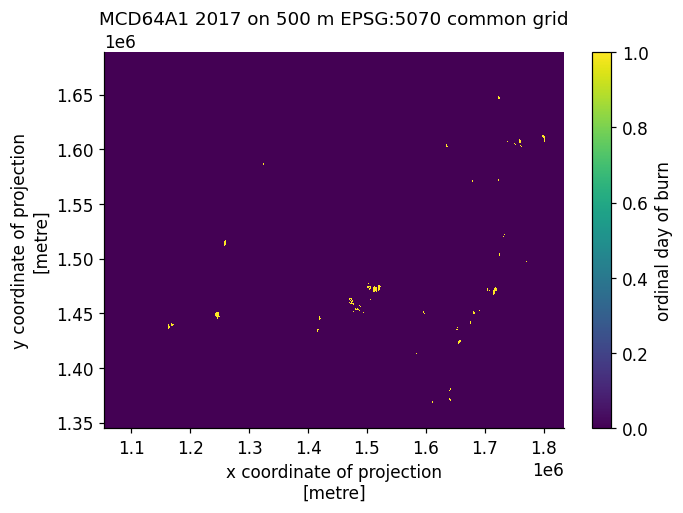

In [9]:
grid = build_common_grid(aoi, res_m=500.0)
print("common grid CRS  :", grid.rio.crs)
print("common grid shape:", dict(grid.sizes))
print("pixel size (m)   :", grid.rio.resolution())

mask_cg = to_common_grid(mask.astype("float32"), grid, how="max") > 0
print("\nmask on common grid -> dims:", dict(mask_cg.sizes), "| CRS:", mask_cg.rio.crs)
mask_cg.astype("uint8").plot(); plt.title(f"{product} {year} on 500 m EPSG:5070 common grid"); plt.show()

## 4. Annual burned-area series — native vs common-grid (Humber Figure 3)

`mode="native"` uses each product's own pixel area; `mode="common_grid"` puts everyone on the shared
500 m grid first. Comparing the two shows how much of any product difference is just resolution.

In [ ]:
products_ba = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311"]   # absent ones skip with a warning
# products_ba = ["FireCCI51"]   # absent ones skip with a warning

years = range(2001, 2022)

area_native = annual_burned_area_series(products_ba, years, aoi, mode="native")
area_cg     = annual_burned_area_series(products_ba, years, aoi, mode="common_grid")
display(area_native.head())
display(area_cg.head())

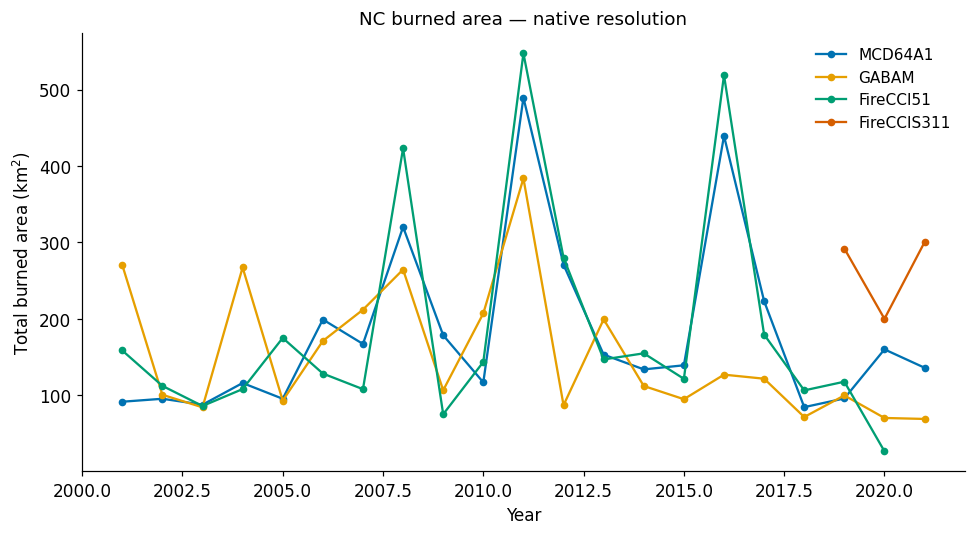

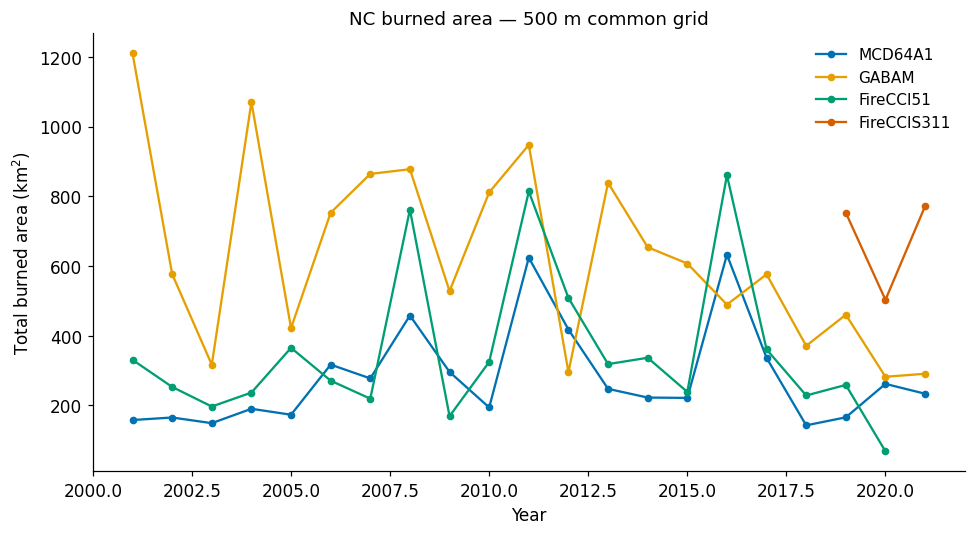

In [ ]:
plot_annual_series(area_native, title="NC burned area — native resolution"); plt.show()
plot_annual_series(area_cg,     title="NC burned area — 500 m common grid"); plt.show()

## 5. Agreement matrices ("confusion-matrix" heatmaps)

VIIRS is included as the independent occurrence check. Binary spatial agreement (Jaccard, kappa) and
temporal correlation of annual totals answer different questions.

In [8]:
products_all = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"]

jac = agreement_matrix(products_all, years, aoi, method="jaccard", pooling="cells")
kap = agreement_matrix(products_all, years, aoi, method="kappa",   pooling="cells")
cor = agreement_matrix(products_ba,  years, aoi, method="pearson", pooling="years")
display(jac.round(2)); display(cor.round(2))

,MCD64A1,GABAM,FireCCI51,FireCCIS311,VIIRS
MCD64A1,1.00,0.09,0.19,0.14,0.07
GABAM,0.09,1.00,0.10,0.08,0.07
FireCCI51,0.19,0.10,1.00,0.10,0.08
FireCCIS311,0.14,0.08,0.10,1.00,0.16
VIIRS,0.07,0.07,0.08,0.16,1.00


,MCD64A1,GABAM,FireCCI51,FireCCIS311
MCD64A1,1.00,0.09,0.85,-0.68
GABAM,0.09,1.00,0.21,0.48
FireCCI51,0.85,0.21,1.00,1.00
FireCCIS311,-0.68,0.48,1.00,1.00


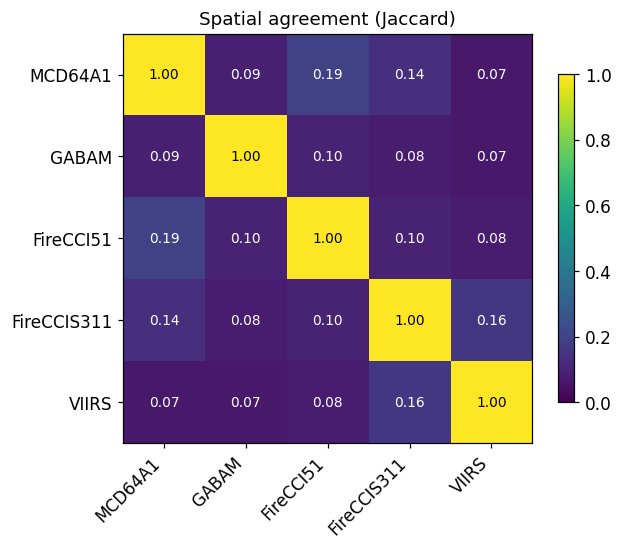

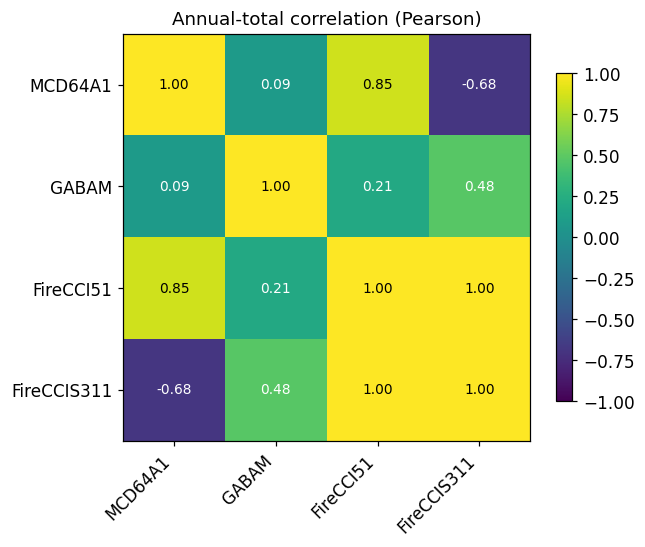

In [9]:
plot_agreement_heatmap(jac, title="Spatial agreement (Jaccard)", vmin=0, vmax=1); plt.show()
plot_agreement_heatmap(cor, title="Annual-total correlation (Pearson)", vmin=-1, vmax=1); plt.show()

## 5b. Pairwise scatterplots — total least squares (Humber-style)

Humber compares two products at a time with **total least squares** (orthogonal regression, which
minimises perpendicular distance — right when *both* axes have error) and reports **RMSE** against the
**y = x** line. Each scatter point is one common-grid cell (our per-spatial-unit analogue of their per-TSA
points), holding that cell's burned fraction.

`tls_slope` near 1 = the two products agree on magnitude; the `tls_slope` matrix is **asymmetric**
(entry [a, b] uses a as x, b as y). RMSE is symmetric. (TLS slope / RMSE on *totals* stay on the
burned-area products, which share km² units.)

n scatter points (cells): 860123
TLS slope, intercept: (0.19940369241838515, 0.0003664673463577383) | RMSE: 0.0297


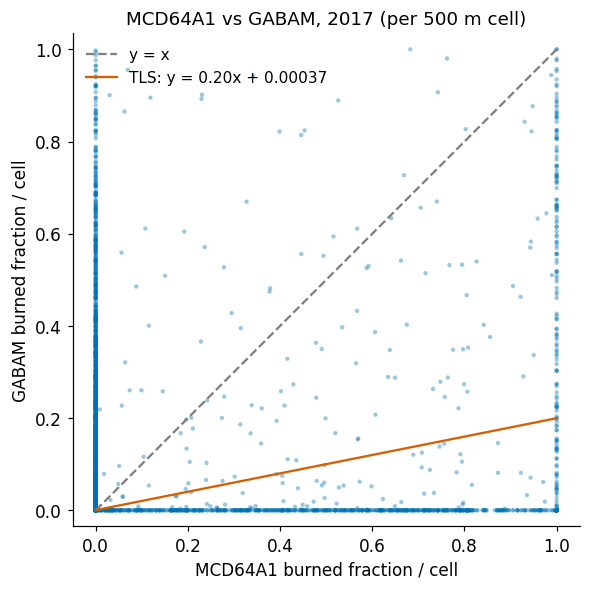

KeyboardInterrupt: 

In [10]:
# scatter of two products' per-cell burned fraction in one year, with TLS + y=x
x, y = product_pair_scatter("MCD64A1", "GABAM", 2017, aoi)
print("n scatter points (cells):", x.size)
if x.size:
    print("TLS slope, intercept:", total_least_squares(x, y), "| RMSE:", round(rmse(x, y), 4))
    plot_product_scatter(
        x, y,
        xlabel="MCD64A1 burned fraction / cell",
        ylabel="GABAM burned fraction / cell",
        title="MCD64A1 vs GABAM, 2017 (per 500 m cell)",
    )
    plt.show()

# TLS-slope and RMSE matrices on per-period totals (burned-area products, km^2)
tls = agreement_matrix(products_ba, years, aoi, method="tls_slope", pooling="years")
err = agreement_matrix(products_ba, years, aoi, method="rmse",      pooling="years")
display(tls.round(2)); display(err.round(1))

## 6. Overlay map for a chosen year

`stack_on_common_grid` aligns every product for the year; `plot_overlay_map` shows where a pair agree
(1 = A only, 2 = B only, 3 = both).

products present in 2017 stack: ['MCD64A1', 'GABAM', 'FireCCI51']


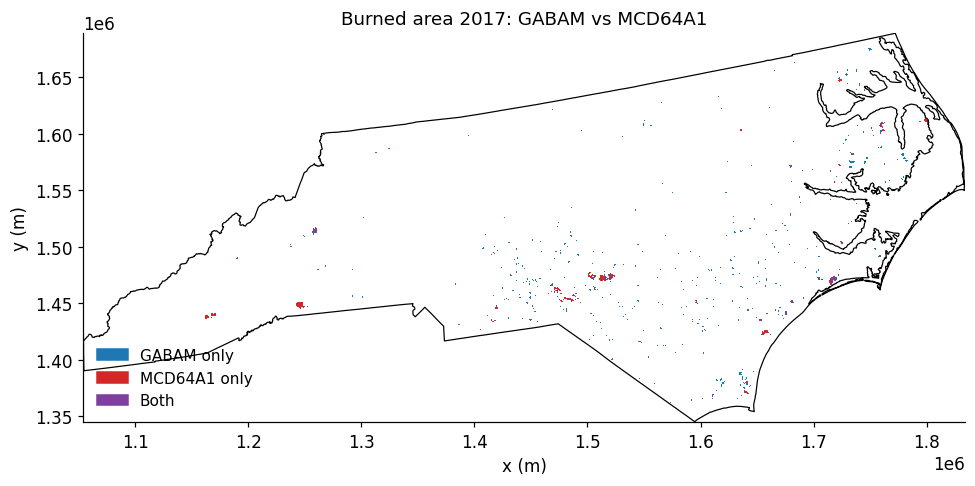

In [11]:
stack_2017 = stack_on_common_grid(products_ba, 2017, aoi, binary=True)
print("products present in 2017 stack:", list(stack_2017))
if {"GABAM", "MCD64A1"} <= set(stack_2017):
    plot_overlay_map(stack_2017, aoi, 2017, pair=("GABAM", "MCD64A1")); plt.show()

## 6b. Multi-product consensus map (all burned-area products at once)

`plot_overlay_map` compares a *pair*; `plot_consensus_map` generalises it to **all** products. Every
product is on the same EPSG:5070 common grid (via `stack_on_common_grid`), and each burned cell is
coloured by **how many** products map a burn there (1 = a single product, N = unanimous). Pass
`month=` for a single month. Bright cells are the agreement core; dim fringe cells are mapped by only
one product.

products present in 2011 stack: ['MCD64A1', 'GABAM', 'FireCCI51']


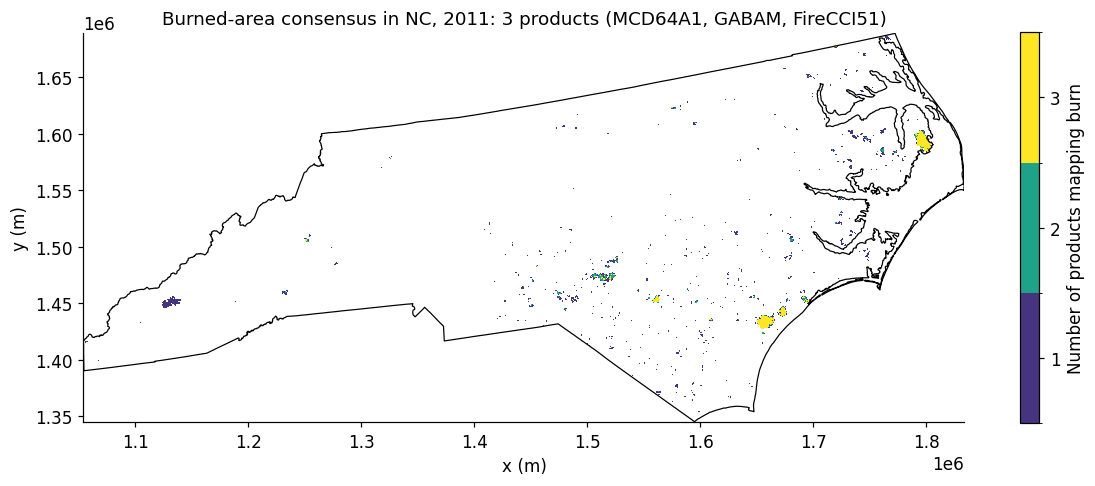

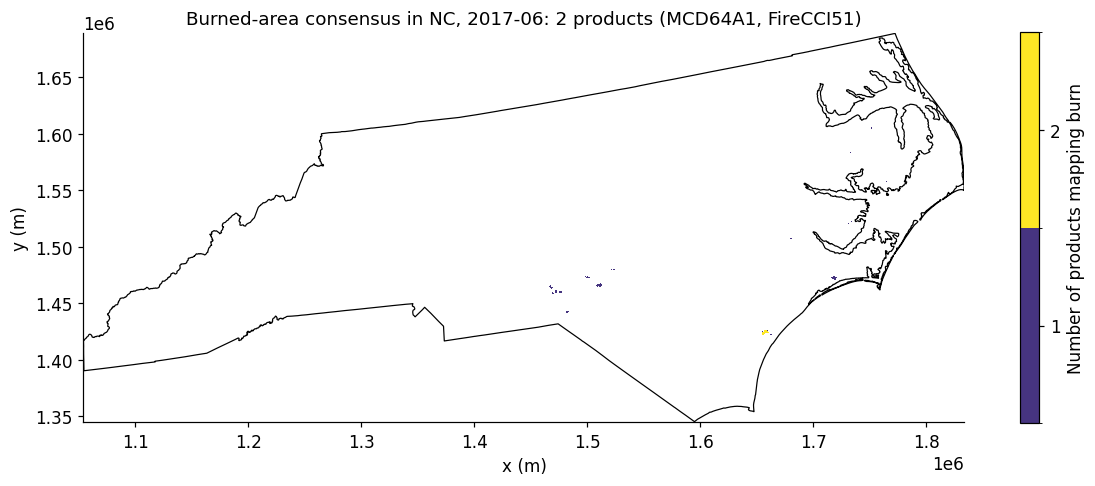

In [14]:
# all burned-area products that have data for the year, on the NC common grid
stack_2011 = stack_on_common_grid(products_ba, 2011, aoi, binary=True)
print("products present in 2011 stack:", list(stack_2011))
fig = plot_consensus_map(stack_2011, aoi, 2011)
plt.show()

# single month works too: pass month= to the stack, then to the plot
stack_2017_06 = stack_on_common_grid(products_ba, 2017, aoi, binary=True, month=6)
if stack_2017_06:
    plot_consensus_map(stack_2017_06, aoi, 2017, month=6); plt.show()

## 7. Monthly mode

One flag: `temporal_unit="month"`. Annual-only products (GABAM, USGS_BA, ...) are dropped; the monthly
products + VIIRS remain. The series index becomes month-start Timestamps.

In [ ]:
area_monthly = annual_burned_area_series(
    ["MCD64A1", "FireCCI51", "FireCCIS311"], range(2017, 2019),
    aoi, mode="common_grid", temporal_unit="month",
)
display(area_monthly.head(14))
plot_annual_series(area_monthly, title="Monthly burned area (2017-2018)"); plt.show()

## 7b. Temporal heat map (Humber-style)

`period_totals_series` gives, per month, burned-area km² for each product and the VIIRS active-fire
**detection count**. `plot_temporal_heatmap` lays this out as products × time, with VIIRS as the bottom
reference row. By default each row is normalised to its own max so the *timing* is comparable across
products despite the different units — bright cells lining up vertically mean a product's burn
detections coincide with active fire.

,MCD64A1,FireCCI51,VIIRS
period,,,
2017-01-01,64.75,0.00,361
2017-02-01,52.25,0.50,1011
2017-03-01,93.25,63.25,1097
2017-04-01,17.00,43.75,600
2017-05-01,24.50,39.75,464
2017-06-01,29.00,60.00,459
2017-07-01,3.00,69.00,323
2017-08-01,0.00,24.50,300
2017-09-01,15.25,50.50,541


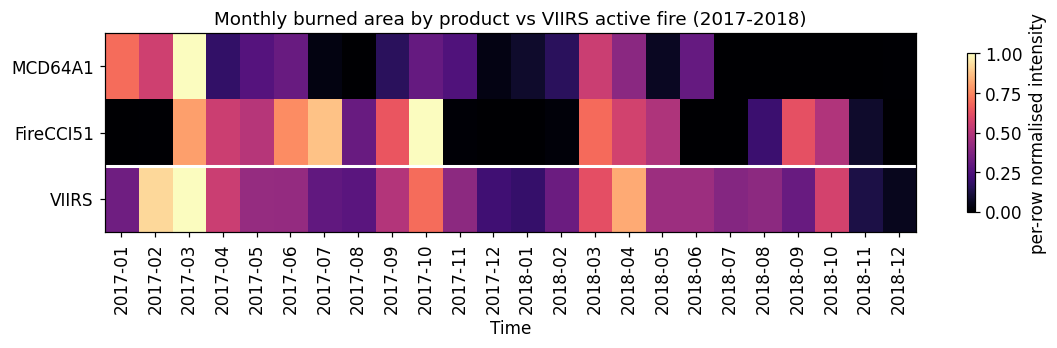

In [15]:
totals_m = period_totals_series(
    ["MCD64A1", "FireCCI51", "FireCCIS311", "VIIRS"], range(2017, 2019),
    aoi, temporal_unit="month",
)
display(totals_m.head(14))
plot_temporal_heatmap(
    totals_m, normalize="row",
    title="Monthly burned area by product vs VIIRS active fire (2017-2018)",
)
plt.show()

In [26]:
products = ["MCD64A1", "FireCCI51", "FireCCIS311", "GABAM", "VIIRS"]
years = range(2012, 2026)          
temporal_unit = "year"
title = f"Yearly burned area by product vs VIIRS active fire ({years[0]}-{years[-1]})"

totals = period_totals_series(products, years, aoi, temporal_unit)
display(totals.head(14))

fig = plot_temporal_heatmap(totals, normalize="row", title=title)

products_save_str = "_".join(products)
fig.savefig(
    f"{products_save_str}_{years[0]}_to_{years[-1]}_temporal_heatmap_by_{temporal_unit}.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

TypeError: 'range' object is not callable

In [20]:
viirs

NameError: name 'viirs' is not defined

## 8. One-call full comparison (writes CSVs)

`compare_fire_products` runs the whole thing and (with `out_dir`) saves every table. Point `aoi` at a
peatland shapefile later and rerun — nothing else changes.

In [ ]:
res = compare_fire_products(
    data_path("processed", "boundaries", "nc_boundary.gpkg"),
    products=["MCD64A1", "GABAM", "FireCCI51", "USGS_BA", "VIIRS"],
    years=range(2001, 2022),
    agreement_methods=("jaccard", "kappa"),
    overlay_years=[2017],
    out_dir=data_path("processed", "fire", "comparison", "nc"),
)
print("result keys:", list(res))
display(res["area_common_grid"].head())
display(res["agreement_jaccard"].round(2))

In [ ]:
# monthly full run (annual-only products auto-dropped)
res_m = compare_fire_products(
    data_path("processed", "boundaries", "nc_boundary.gpkg"),
    years=range(2017, 2019),
    temporal_unit="month",
    overlay_years=[(2017, 6)],
    out_dir=data_path("processed", "fire", "comparison", "nc_monthly"),
)
print("monthly result keys:", list(res_m))
display(res_m["area_common_grid"].head(14))